# Project 1 - part 1

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import chisquare

## Task 1

0: efter operation (ingen cancer)

1: lokal recurrence

2: distant

3: both lokal and distant

4: death

In [11]:
random.seed(42)
np.random.seed(42)
n = 1000 # antal kvinder
P = np.array([
    [0.9915, 0.005,  0.0025, 0, 0.001],
    [0, 0.986,  0.005,  0.004,  0.005],
    [0, 0, 0.992,  0.003,  0.005],
    [0, 0, 0, 0.991,  0.009],
    [0, 0, 0, 0, 1]
])

def simulate_one(P, start_state=0):
    state = start_state
    months = 0
    ever_local = False  # om hun nogensinde har lokal komponent (1 eller 3)

    while state != 4:  # 4 = death
        # tjek lokal komponent
        if state == 1 or state == 3:
            ever_local = True

        state = np.random.choice(len(P), p=P[state])
        months += 1

    return months, ever_local


def simulate_many(P, n):
    lifetimes = []
    local_flags = []

    for _ in range(n):
        t, ever_local = simulate_one(P)
        lifetimes.append(t)
        local_flags.append(ever_local)

    return np.array(lifetimes), np.array(local_flags)

lifetimes, local_flags = simulate_many(P=P, n=n)


In [12]:
random.seed(42)
np.random.seed(42)

n_local = local_flags.sum()
prop_local = n_local / n
print(f"{n_local} ud af {n} kvinder ({prop_local:.3f}) får lokal recurrence på et tidspunkt.")

712 ud af 1000 kvinder (0.712) får lokal recurrence på et tidspunkt.


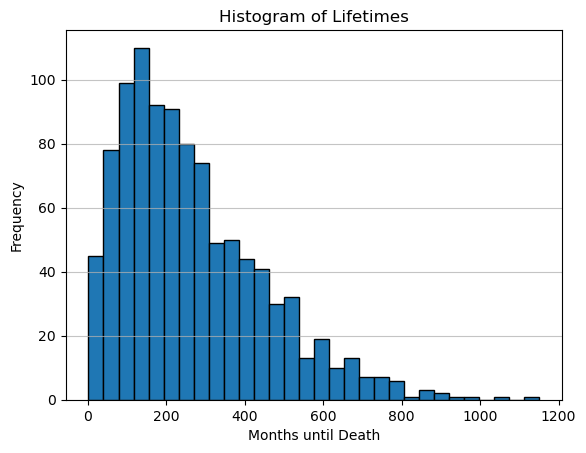

In [13]:
plt.hist(lifetimes, bins=30, edgecolor='black')
plt.title('Histogram of Lifetimes')
plt.xlabel('Months until Death')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Task 2

In [ ]:
random.seed(42)
np.random.seed(42)

n = 1000
def simulate_state_at_t(P, t_max=120, start_state=0):
    state = start_state
    for _ in range(t_max):
        state = np.random.choice(len(P), p=P[state])
    return state

def simulate_states_at_120(P, n):
    states = []
    for _ in range(n):
        s = simulate_state_at_t(P, t_max=120)
        states.append(s)
    return np.array(states)

states_120 = simulate_states_at_120(P, n)


In [15]:
random.seed(42)
np.random.seed(42)

counts = np.bincount(states_120, minlength=5)
empirical_dist = counts / 1000
print("Empirical distribution at t=120:", empirical_dist)


Empirical distribution at t=120: [0.346 0.181 0.179 0.069 0.225]


In [16]:
random.seed(42)
np.random.seed(42)

p0 = np.array([1, 0, 0, 0, 0])
P120 = np.linalg.matrix_power(P, 120)
theoretical_dist = p0 @ P120
print("Theoretical distribution at t=120:", theoretical_dist)

Theoretical distribution at t=120: [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]


In [19]:
random.seed(42)
np.random.seed(42)

expected_counts = 1000 * theoretical_dist
chi2, p_value = chisquare(counts, expected_counts)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)


Chi-square statistic: 6.7236992880743305
p-value: 0.15122999635033527


## Task 3

Forkert tror jeg

In [20]:
random.seed(42)
np.random.seed(42)

pi = np.array([1, 0, 0, 0])
Ps = P[:4, :4]
ps = P[:4, 4]   # shape (4,)
I = np.eye(Ps.shape[0])
ones = np.ones(Ps.shape[0])

E_T_theoretical = pi @ np.linalg.inv(I - Ps) @ ones
print("Theoretical mean lifetime (months):", E_T_theoretical)

Theoretical mean lifetime (months): 262.3716153127931


In [21]:
random.seed(42)
np.random.seed(42)

E_T_empirical = lifetimes.mean()
print("Empirical mean lifetime (months):", E_T_empirical)

Empirical mean lifetime (months): 265.035


In [24]:
random.seed(42)
np.random.seed(42)

t_max = 600
pmf = np.zeros(t_max + 1)

M = np.eye(Ps.shape[0])
for t in range(t_max + 1):
    pmf[t] = pi @ M @ ps
    M = M @ Ps

pmf = pmf / pmf.sum()

counts = np.zeros(t_max + 1, dtype=int)

for t in lifetimes:
    if t <= t_max:
        counts[t] += 1
    else:
        counts[t_max] += 1

expected = n * pmf

chi2, p_value = chisquare(counts, expected)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)


Chi-square statistic: 8836.887251086593
p-value: 0.0


## Task 4

In [31]:
random.seed(42)
np.random.seed(42)

def simulate_one_with_recurrence(P, start_state=0):
    state = start_state
    months = 0
    recurrence_time = None  # tidspunkt for første recidiv

    while state != 4:  # 4 = death
        # registrér recidiv (lokal = 1, regional = 2, distant = 3)
        if recurrence_time is None and state in [1, 2, 3]:
            recurrence_time = months

        # næste måned
        state = np.random.choice(len(P), p=P[state])
        months += 1

    return months, recurrence_time

def estimate_lifetime_given_conditions(P, target_n):
    accepted_lifetimes = []

    while len(accepted_lifetimes) < target_n:
        lifetime, rec_time = simulate_one_with_recurrence(P)

        alive_after_12 = lifetime > 12
        recurrence_within_12 = (rec_time is not None and rec_time <= 12)

        if alive_after_12 and recurrence_within_12:
            accepted_lifetimes.append(lifetime)

    return np.array(accepted_lifetimes)


In [32]:
random.seed(42)
np.random.seed(42)

accepted = estimate_lifetime_given_conditions(P, target_n=1000)
expected_lifetime = accepted.mean()

print("Estimated expected lifetime:", expected_lifetime)

Estimated expected lifetime: 178.715


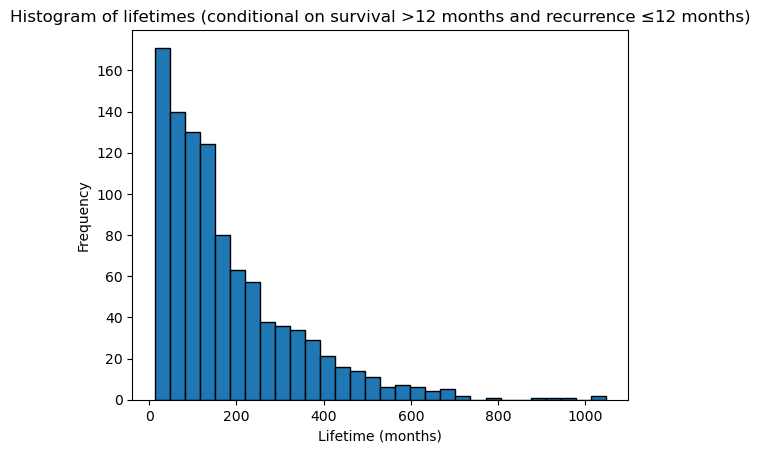

In [36]:
plt.hist(accepted, bins=30, edgecolor='black')
plt.xlabel("Lifetime (months)")
plt.ylabel("Frequency")
plt.title("Histogram of lifetimes (conditional on survival >12 months and recurrence ≤12 months)")
plt.show()

In [34]:
random.seed(42)
np.random.seed(42)

mean_est = np.mean(accepted)
std_est = np.std(accepted, ddof=1)
n = len(accepted)

ci_low = mean_est - 1.96 * std_est / np.sqrt(n)
ci_high = mean_est + 1.96 * std_est / np.sqrt(n)

print("Mean lifetime:", mean_est)
print("95% CI: [", ci_low, ",", ci_high, "]")


Mean lifetime: 178.715
95% CI: [ 169.16054324749567 , 188.26945675250434 ]


## Part 5

In [37]:
random.seed(42)
np.random.seed(42)

def simulate_women(P):
    lifetimes = []
    for _ in range(200):
        t, _ = simulate_one(P)
        lifetimes.append(t)
    lifetimes = np.array(lifetimes)

    # crude estimator: fraction dying before 350 months
    crude = np.mean(lifetimes <= 350)

    # control variate: sample mean lifetime
    C = np.mean(lifetimes)

    return crude, C


def run_task5(P, theoretical_mean, runs=100):
    crude_vals = []
    cv_vals = []

    for _ in range(runs):
        crude, C = simulate_women(P)
        crude_vals.append(crude)

        cv_vals.append((crude, C))

    crude_vals = np.array(crude_vals)

    # Estimate b using all runs
    crude_arr = np.array([x[0] for x in cv_vals])
    C_arr = np.array([x[1] for x in cv_vals])

    b = np.cov(crude_arr, C_arr, ddof=1)[0,1] / np.var(C_arr, ddof=1)

    # Apply control variate correction
    theta_cv = crude_arr - b * (C_arr - theoretical_mean)

    return crude_arr, theta_cv, b


In [38]:
theoretical_mean = 1 / (1 - P[:4,:4]).sum()  # <-- du indsætter din værdi fra Task 3

crude, cv, b = run_task5(P, theoretical_mean)

var_crude = np.var(crude, ddof=1)
var_cv = np.var(cv, ddof=1)

print("Variance crude:", var_crude)
print("Variance CV:", var_cv)
print("Reduction factor:", var_crude / var_cv)
print("b =", b)


Variance crude: 0.0013012601010101014
Variance CV: 0.00030909928787620444
Reduction factor: 4.209845030543265
b = -0.0020944350467828206
